In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

print("All libraries imported successfully!")
data = fetch_california_housing(as_frame=True)
print(f"Dataset loaded! Shape: {data.data.shape}")

All libraries imported successfully!
Dataset loaded! Shape: (20640, 8)


In [20]:
# Load the California Housing dataset
data = fetch_california_housing(as_frame=True)

# Combine features and target into one dataframe
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

# Look at first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [21]:
# Check shape, data types and missing values
print("Dataset Shape:", df.shape)
print("\n--- Column Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Basic Statistics ---")
df.describe()

Dataset Shape: (20640, 9)

--- Column Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

--- Missing Values ---
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

--- Basic Statistics ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


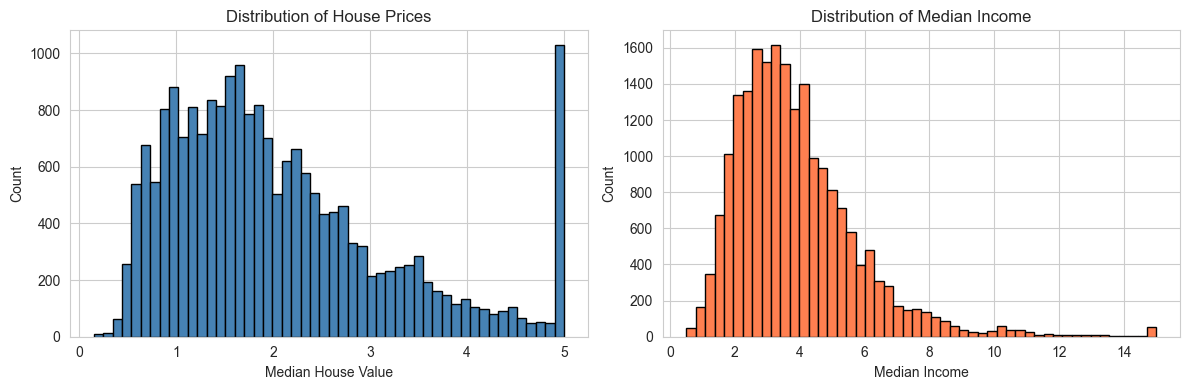

In [22]:
# Set the style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Distribution of House Prices
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['MedHouseVal'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Count")

# 2. Distribution of Median Income
plt.subplot(1, 2, 2)
df['MedInc'].hist(bins=50, color='coral', edgecolor='black')
plt.title("Distribution of Median Income")
plt.xlabel("Median Income")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

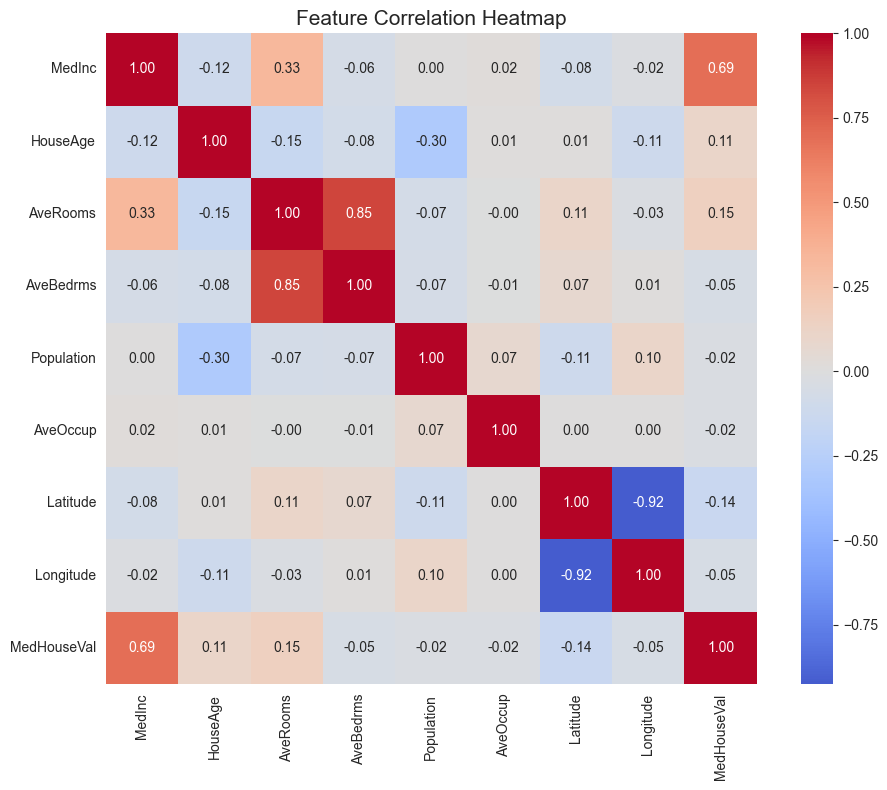

In [23]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,          # show numbers
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # red-blue color scheme
    center=0,
    square=True
)
plt.title("Feature Correlation Heatmap", fontsize=15)
plt.tight_layout()
plt.show()

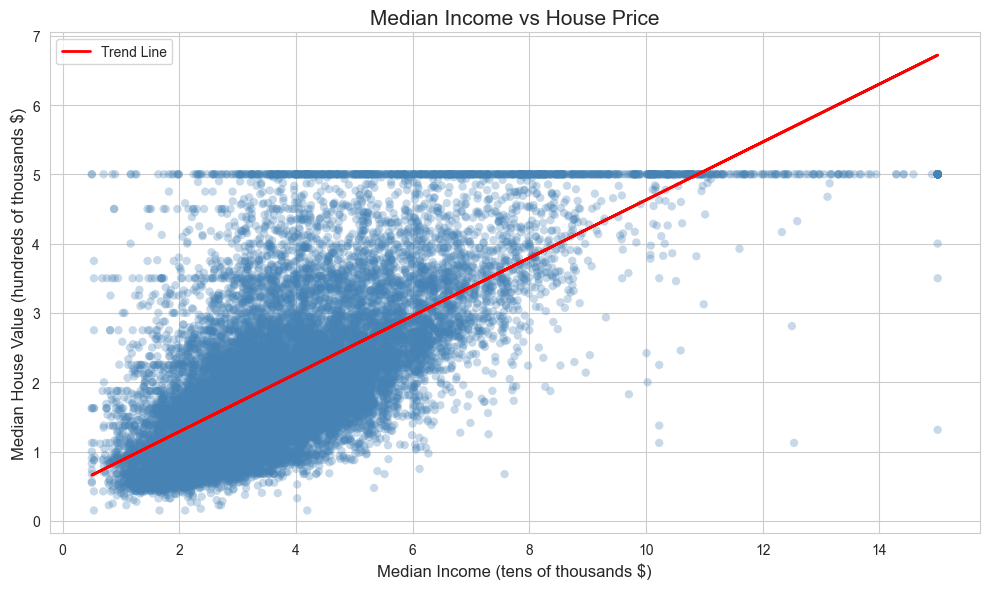

Trend: For every $10k increase in income, house price increases by $0.418 hundred thousand


In [24]:
# Scatter plot - Income vs House Price
plt.figure(figsize=(10, 6))
plt.scatter(
    df['MedInc'], 
    df['MedHouseVal'],
    alpha=0.3,           # transparency so overlapping points visible
    color='steelblue',
    edgecolors='none'
)
plt.title("Median Income vs House Price", fontsize=15)
plt.xlabel("Median Income (tens of thousands $)", fontsize=12)
plt.ylabel("Median House Value (hundreds of thousands $)", fontsize=12)

# Add trend line
m, b = np.polyfit(df['MedInc'], df['MedHouseVal'], 1)
plt.plot(df['MedInc'], m * df['MedInc'] + b, color='red', linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Trend: For every $10k increase in income, house price increases by ${m:.3f} hundred thousand")

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split data - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Confirm shapes
print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)
print("\nFeatures used:", list(X.columns))
print("\n✅ Data is ready for training!")


Training set size: (16512, 8)
Testing set size:  (4128, 8)

Features used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

✅ Data is ready for training!


In [26]:
from sklearn.linear_model import LinearRegression

# Create and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred = model.predict(X_test_scaled)

print("✅ Model trained successfully!")
print("\n--- Model Coefficients ---")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:15} : {coef:.4f}")
print(f"\n  Intercept      : {model.intercept_:.4f}")

✅ Model trained successfully!

--- Model Coefficients ---
  MedInc          : 0.8544
  HouseAge        : 0.1225
  AveRooms        : -0.2944
  AveBedrms       : 0.3393
  Population      : -0.0023
  AveOccup        : -0.0408
  Latitude        : -0.8969
  Longitude       : -0.8698

  Intercept      : 2.0719


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Fixed: manually square root
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.4f}")
print(f"  R²   (R-Squared Score)      : {r2:.4f}")
print("=" * 40)

# Interpretation
print("\n--- What these mean ---")
print(f"  ● Average prediction error     : ${mae*100:.1f}k")
print(f"  ● Typical prediction error     : ${rmse*100:.1f}k")
print(f"  ● Model explains {r2*100:.1f}% of price variation")

if r2 >= 0.6:
    print("\n✅ Good model for a baseline Linear Regression!")
else:
    print("\n⚠️ Model needs improvement!")

       MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error)  : 0.5332
  RMSE (Root Mean Sq. Error)  : 0.7456
  R²   (R-Squared Score)      : 0.5758

--- What these mean ---
  ● Average prediction error     : $53.3k
  ● Typical prediction error     : $74.6k
  ● Model explains 57.6% of price variation

⚠️ Model needs improvement!


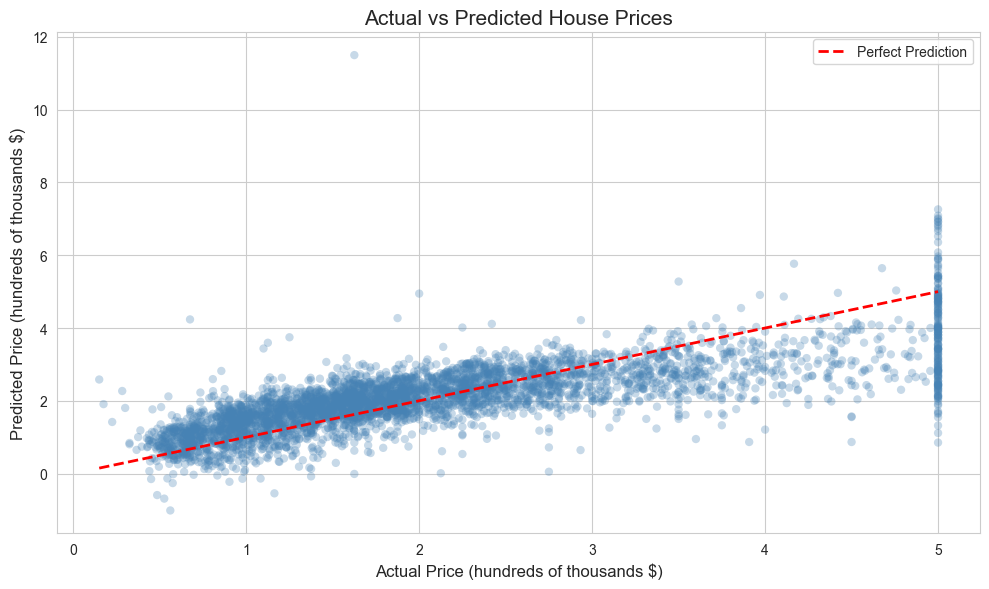

In [28]:
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linewidth=2, linestyle='--', label='Perfect Prediction'
)

plt.title("Actual vs Predicted House Prices", fontsize=15)
plt.xlabel("Actual Price (hundreds of thousands $)", fontsize=12)
plt.ylabel("Predicted Price (hundreds of thousands $)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

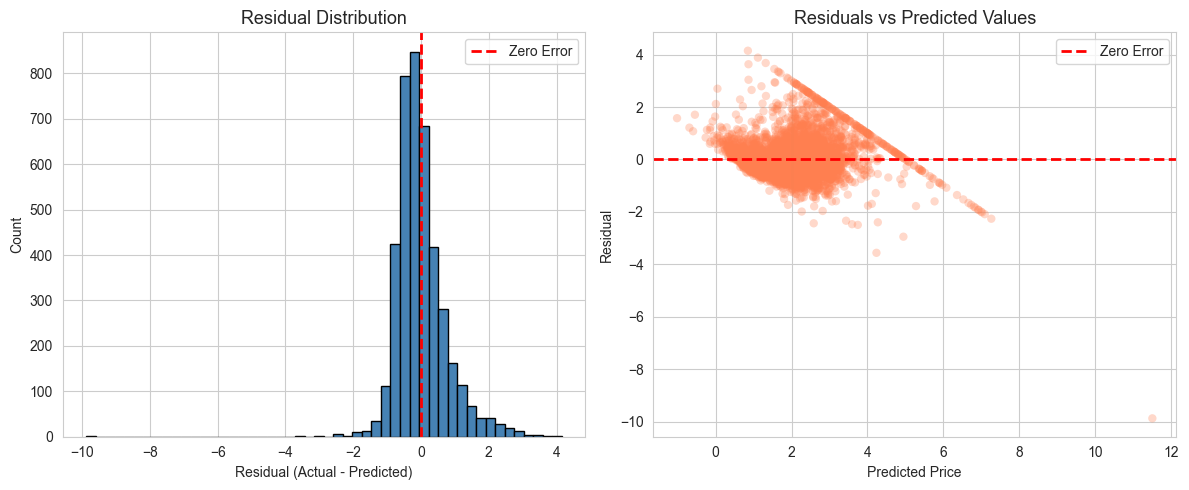

Mean Residual  : 0.0035  (closer to 0 = better)
Std Residual   : 0.7457


In [29]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))

# Plot 1 - Residual Distribution
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linewidth=2, linestyle='--', label='Zero Error')
plt.title("Residual Distribution", fontsize=13)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()

# Plot 2 - Residuals vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='none')
plt.axhline(0, color='red', linewidth=2, linestyle='--', label='Zero Error')
plt.title("Residuals vs Predicted Values", fontsize=13)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.legend()

plt.tight_layout()
plt.show()

# Residual stats
print(f"Mean Residual  : {residuals.mean():.4f}  (closer to 0 = better)")
print(f"Std Residual   : {residuals.std():.4f}")

In [30]:
import pickle
import os

# Save the model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the scaler too (important for predictions!)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as house_price_model.pkl")
print("✅ Scaler saved as scaler.pkl")
print(f"\nSaved location: {os.getcwd()}")
print("\n--- Files in your project folder ---")
for file in os.listdir():
    print(f"  📄 {file}")
    

✅ Model saved as house_price_model.pkl
✅ Scaler saved as scaler.pkl

Saved location: c:\Users\abhis\house_price_predictor

--- Files in your project folder ---
  📄 house_price_model.pkl
  📄 scaler.pkl
  📄 task1_ml_linear_regression.ipynb


In [31]:
mport pickle
import os

# Save the model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the scaler too (important for predictions!)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as house_price_model.pkl")
print("✅ Scaler saved as scaler.pkl")
print(f"\nSaved location: {os.getcwd()}")
print("\n--- Files in your project folder ---")
for file in os.listdir():
    print(f"  📄 {file}")

SyntaxError: invalid syntax (3089612182.py, line 1)

In [ ]:
import pickle
import os

# Save the model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the scaler too (important for predictions!)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as house_price_model.pkl")
print("✅ Scaler saved as scaler.pkl")
print(f"\nSaved location: {os.getcwd()}")
print("\n--- Files in your project folder ---")
for file in os.listdir():
    print(f"  📄 {file}")
    

✅ Model saved as house_price_model.pkl
✅ Scaler saved as scaler.pkl

Saved location: c:\Users\abhis\house_price_predictor

--- Files in your project folder ---
  📄 house_price_model.pkl
  📄 scaler.pkl
  📄 task1_ml_linear_regression.ipynb


In [ ]:
# Predict on a new house
new_house = pd.DataFrame({
    'MedInc'    : [8.0],      # High income neighborhood
    'HouseAge'  : [20.0],     # 20 year old house
    'AveRooms'  : [6.0],      # 6 rooms average
    'AveBedrms' : [1.0],      # 1 bedroom average
    'Population': [300.0],    # 300 people in block
    'AveOccup'  : [2.5],      # 2.5 people per house
    'Latitude'  : [37.88],    # San Francisco area
    'Longitude' : [-122.23]
})

# Scale and predict
new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)

print("=" * 40)
print("       NEW HOUSE PREDICTION")
print("=" * 40)
print(f"\n  📍 Location    : San Francisco Area")
print(f"  🏠 House Age   : 20 years")
print(f"  💰 Med Income  : $80,000")
print(f"  👥 Population  : 300")
print("=" * 40)
print(f"\n  🏷️  Predicted Price : ${predicted_price[0]*100:.1f}k")
print(f"  🏷️  Predicted Price : ${predicted_price[0]:.4f} (hundreds of thousands)")
print("\n✅ Prediction complete!")


       NEW HOUSE PREDICTION

  📍 Location    : San Francisco Area
  🏠 House Age   : 20 years
  💰 Med Income  : $80,000
  👥 Population  : 300

  🏷️  Predicted Price : $390.5k
  🏷️  Predicted Price : $3.9048 (hundreds of thousands)

✅ Prediction complete!


In [ ]:
print("=" * 50)
print("        PROJECT SUMMARY REPORT")
print("=" * 50)

print(f"""
📊 DATASET
  ● Name        : California Housing Dataset
  ● Total rows  : {df.shape[0]:,}
  ● Features    : {df.shape[1]-1}
  ● Target      : Median House Value

🔍 EDA FINDINGS
  ● No missing values found
  ● MedInc has strongest correlation (0.69)
  ● House prices capped at $500k in dataset
  ● Most houses valued between $100k-$300k

🤖 MODEL
  ● Algorithm   : Linear Regression
  ● Training    : {X_train.shape[0]:,} samples (80%)
  ● Testing     : {X_test.shape[0]:,} samples (20%)

📈 RESULTS
  ● MAE         : {mae:.4f} (${mae*100:.1f}k avg error)
  ● RMSE        : {rmse:.4f} (${rmse*100:.1f}k typical error)
  ● R² Score    : {r2:.4f} ({r2*100:.1f}% variance explained)

💡 IMPROVEMENT IDEAS
  ● Try Ridge or Lasso Regression
  ● Try Random Forest or XGBoost
  ● Add feature engineering
  ● Remove outliers before training
  ● Use cross validation

💾 SAVED FILES
  ● house_price_model.pkl
  ● scaler.pkl
  ● task1_ml_linear_regression.ipynb
""")
print("=" * 50)
print("✅ Project Complete!")
print("=" * 50)

        PROJECT SUMMARY REPORT

📊 DATASET
  ● Name        : California Housing Dataset
  ● Total rows  : 20,640
  ● Features    : 8
  ● Target      : Median House Value

🔍 EDA FINDINGS
  ● No missing values found
  ● MedInc has strongest correlation (0.69)
  ● House prices capped at $500k in dataset
  ● Most houses valued between $100k-$300k

🤖 MODEL
  ● Algorithm   : Linear Regression
  ● Training    : 16,512 samples (80%)
  ● Testing     : 4,128 samples (20%)

📈 RESULTS
  ● MAE         : 0.5332 ($53.3k avg error)
  ● RMSE        : 0.7456 ($74.6k typical error)
  ● R² Score    : 0.5758 (57.6% variance explained)

💡 IMPROVEMENT IDEAS
  ● Try Ridge or Lasso Regression
  ● Try Random Forest or XGBoost
  ● Add feature engineering
  ● Remove outliers before training
  ● Use cross validation

💾 SAVED FILES
  ● house_price_model.pkl
  ● scaler.pkl
  ● task1_ml_linear_regression.ipynb

✅ Project Complete!
